In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAI
from dotenv import load_dotenv


In [3]:
load_dotenv()

True

In [4]:
llm=ChatGoogleGenerativeAI(
    model="gemini-3.5-flash"
)

In [5]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int
    bpb:int
    sr:int

In [6]:
def calculate_bpb(State:BatsmanState)->BatsmanState:
    bpb=State['runs']/(State['fours']+State['sixes'])
    State['bpb']=bpb
    
    return {'bpb':bpb}

In [7]:
def calculate_sr(State:BatsmanState)->BatsmanState:
    sr=(State['runs']/State['balls'])*100
    State['sr']=sr
    
    return {'sr':sr}

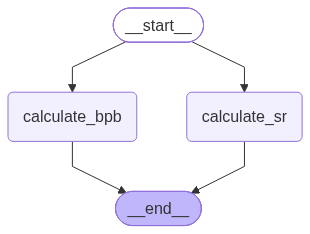

In [13]:
graph=StateGraph(BatsmanState)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_sr',calculate_sr)
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_sr')
graph.add_edge('calculate_bpb',END)
graph.add_edge('calculate_sr',END)

workflow=graph.compile()
workflow

In [12]:
initial_state={
    'runs':100,
    'balls':35,
    'fours':6,
    'sixes':8
}
final_state=workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 35, 'fours': 6, 'sixes': 8, 'bpb': 7.142857142857143, 'sr': 285.7142857142857}
